# Does Environmental Performance Drive Economic Growth?
### A Cross-Country Regression Analysis Using World Bank Sovereign ESG Data

**Nikhilvarma Kandula** 

---

**Research Question:** *Do countries with lower CO₂ emissions and higher renewable energy usage show stronger economic growth?*

**Dataset:** [World Bank Sovereign ESG Data Portal](https://datacatalog.worldbank.org/search/dataset/0037651/environment-social-and-governance-data) — Bulk CSV, all countries, 1960–2023, 17 sustainability themes  

**Scope:** OECD countries, 2010–2023  

**Variables:**
- **Independent Variable 1 (IV₁):** CO₂ emissions, metric tons per capita (`EN.ATM.CO2E.PC`)
- **Independent Variable 2 (IV₂):** Renewable energy consumption, % of total final energy consumption (`EG.FEC.RNEW.ZS`)
- **Dependent Variable (DV):** GDP growth, annual % (`NY.GDP.MKTP.KD.ZG`)

## 1. Literature Review

The link between environmental sustainability and macroeconomic performance has been widely studied in recent years — especially as governments try to balance green transition policies with economic growth targets.

**Angelidis et al. (2024)** built a world-level ESG index using firm data from 46 countries and showed that higher ESG scores are a strong predictor of future GDP growth, industrial production, and unemployment trends. Their dynamic panel regression approach highlights that sustainability metrics carry real macroeconomic signal beyond traditional financial variables.

**Dkhili (2019)** looked at MENA countries specifically and found a threshold effect — environmental performance only starts contributing positively to economic growth after reaching a certain minimum level. Below that threshold, the relationship is actually negative. This was estimated using a panel smooth transition regression (PSTR) model.

**Mirziyoyeva & Salahodjaev, (2023)** examined CO₂ emissions, renewable energy, and GDP in highly globalized countries using system GMM estimators. Their findings support the Environmental Kuznets Curve (EKC) hypothesis — the idea that emissions rise with early economic growth but eventually decline as countries adopt cleaner energy.

Our analysis takes a simpler but focused approach: we test whether CO₂ emissions per capita and renewable energy share have a measurable linear association with GDP growth across 38 OECD countries (2010–2023), using OLS regression. We acknowledge this is a more limited methodology compared to the dynamic panel models in the literature, but it provides a clear baseline for understanding these relationships.

## 2. Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_breuschpagan, normal_ad
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import warnings
warnings.filterwarnings('ignore')

# color palette we'll use throughout
TEAL  = '#00C6B2'
BLACK = '#1C1C1C'
GREY  = '#7F8C8D'
WHITE = '#FFFFFF'
CORAL = '#FF6B6B'
AMBER = '#F39C12'

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({
    'figure.figsize': (10, 5),
    'axes.edgecolor': BLACK,
    'axes.labelcolor': BLACK,
    'text.color': BLACK,
    'xtick.color': BLACK,
    'ytick.color': BLACK,
    'axes.titleweight': 'bold',
    'axes.titlesize': 13,
    'figure.dpi': 120,
    'savefig.dpi': 150,
    'savefig.bbox': 'tight'
})

print("All libraries loaded.")

All libraries loaded.


## 3. Loading the Dataset

The World Bank ESG dataset comes in wide format — each row is one country-indicator pair, and the columns are years from 1960 to 2023. We need to reshape this later.

In [2]:
df_raw = pd.read_csv('ESGCSV.csv')

print(f"Dataset size: {df_raw.shape[0]:,} rows, {df_raw.shape[1]} columns")
print(f"Year range: 1960 to 2023")
print(f"Unique countries/regions: {df_raw['Country Code'].nunique()}")
print(f"Unique indicators: {df_raw['Indicator Code'].nunique()}")
df_raw.head(3)

Dataset size: 16,969 rows, 68 columns
Year range: 1960 to 2023
Unique countries/regions: 239
Unique indicators: 71


,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Arab World,ARB,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,86.082150,86.321160,86.491156,86.583767,86.523897,86.527129,86.503099,86.347769,86.449919,NaN
1,Arab World,ARB,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,88.406777,88.661643,89.186171,90.351067,88.689841,89.928996,90.241777,90.434095,90.654518,91.64543
2,Arab World,ARB,Adjusted savings: natural resources depletion ...,NY.ADJ.DRES.GN.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,10.200009,6.245928,5.406433,6.465929,8.238448,7.278235,4.628360,NaN,NaN,NaN


### 3.1 Checking Our Target Indicators

We need three specific indicators from the dataset. Let's make sure they exist before we go further.

In [3]:
targets = {
    'EN.ATM.CO2E.PC':    '$CO_2$ emissions (metric tons per capita)',
    'EG.FEC.RNEW.ZS':   'Renewable energy consumption (% of total)',
    'NY.GDP.MKTP.KD.ZG': 'GDP growth (annual %)'
}

for indicator_code, description in targets.items():
    exists = indicator_code in df_raw['Indicator Code'].values
    mark = '✅' if exists else '❌'
    print(f"{mark} {indicator_code} — {description}")

✅ EN.ATM.CO2E.PC — $CO_2$ emissions (metric tons per capita)
✅ EG.FEC.RNEW.ZS — Renewable energy consumption (% of total)
✅ NY.GDP.MKTP.KD.ZG — GDP growth (annual %)


## 4. Filtering for OECD Countries (2010–2023)

The World Bank metadata doesn't tag which countries belong to the OECD, so we define the list manually based on current OECD membership (38 countries). The actual data values all come from the CSV — this is just a filter.

Source: https://www.oecd.org/about/members-and-partners/

In [4]:
# current OECD members — 38 countries
oecd_countries = [
    'AUS', 'AUT', 'BEL', 'CAN', 'CHL', 'COL', 'CRI', 'CZE',
    'DNK', 'EST', 'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'ISL',
    'IRL', 'ISR', 'ITA', 'JPN', 'KOR', 'LVA', 'LTU', 'LUX',
    'MEX', 'NLD', 'NZL', 'NOR', 'POL', 'PRT', 'SVK', 'SVN',
    'ESP', 'SWE', 'CHE', 'TUR', 'GBR', 'USA'
]

year_columns = [str(y) for y in range(2010, 2024)]

print(f"Filtering for {len(oecd_countries)} OECD countries")
print(f"Time window: {year_columns[0]} to {year_columns[-1]}")

Filtering for 38 OECD countries
Time window: 2010 to 2023


### 4.1 Filtering & Reshaping to Long Format

We keep only OECD rows for our three indicators, then melt the year columns into a proper long-format table — one row per observation (country + year + indicator).

In [5]:
# keep only what we need
df_filtered = df_raw[
    (df_raw['Country Code'].isin(oecd_countries)) &
    (df_raw['Indicator Code'].isin(targets.keys()))
].copy()

print(f"Rows after filtering: {len(df_filtered)}")

# reshape from wide to long
id_vars = ['Country Name', 'Country Code', 'Indicator Code']
df_long = df_filtered.melt(
    id_vars=id_vars,
    value_vars=year_columns,
    var_name='Year',
    value_name='Value'
)

# clean up types
df_long['Year'] = df_long['Year'].astype(int)
df_long['Value'] = pd.to_numeric(df_long['Value'], errors='coerce')

print(f"Long format: {df_long.shape[0]} rows, {df_long.shape[1]} columns")
df_long.head()

Rows after filtering: 114
Long format: 1596 rows, 5 columns


,Country Name,Country Code,Indicator Code,Year,Value
0,Australia,AUS,EN.ATM.CO2E.PC,2010,17.973752
1,Australia,AUS,NY.GDP.MKTP.KD.ZG,2010,2.219980
2,Australia,AUS,EG.FEC.RNEW.ZS,2010,8.200000
3,Austria,AUT,EN.ATM.CO2E.PC,2010,8.365625
4,Austria,AUT,NY.GDP.MKTP.KD.ZG,2010,1.808982


### 4.2 Creating the Analysis Table

Now we pivot so each indicator gets its own column. This gives us a clean table where each row is one country in one year, with CO₂, Renewable %, and GDP Growth as separate columns.

In [6]:
df_pivot = df_long.pivot_table(
    index=['Country Name', 'Country Code', 'Year'],
    columns='Indicator Code',
    values='Value'
).reset_index()

df_pivot.columns.name = None

# shorter column names
df_pivot = df_pivot.rename(columns={
    'EN.ATM.CO2E.PC':    'CO2_per_capita',
    'EG.FEC.RNEW.ZS':   'Renewable_pct',
    'NY.GDP.MKTP.KD.ZG': 'GDP_growth'
})

print(f"Pivot table: {df_pivot.shape}")
print(f"\nMissing values per column:")
print(df_pivot[['CO2_per_capita', 'Renewable_pct', 'GDP_growth']].isnull().sum())

Pivot table: (532, 6)

Missing values per column:
CO2_per_capita    114
Renewable_pct      76
GDP_growth          0
dtype: int64


### 4.3 Dropping Incomplete Rows

We remove any row where one of the three key variables is missing. This way all our analyses run on the same complete dataset.

In [7]:
df = df_pivot.dropna(subset=['CO2_per_capita', 'Renewable_pct', 'GDP_growth']).copy()

print(f"Rows with complete data: {len(df)}")
print(f"Countries: {df['Country Code'].nunique()}")
print(f"Year range: {df['Year'].min()} – {df['Year'].max()}")

Rows with complete data: 418
Countries: 38
Year range: 2010 – 2020


## 5. Descriptive Statistics

Before running any models, we look at the basic distribution of our variables — central tendency, spread, and shape.

In [8]:
cols = ['CO2_per_capita', 'Renewable_pct', 'GDP_growth']

desc = df[cols].describe().T
desc['skewness'] = df[cols].skew()
desc['kurtosis'] = df[cols].kurtosis()

# nicer row names
desc.index = ['$CO_2$ Emissions (t/capita)', 'Renewable Energy (%)', 'GDP Growth (%)']
desc.round(3)

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
$CO_2$ Emissions (t/capita),418.0,7.437,3.872,1.384,4.704,6.710,8.876,21.756,1.135,1.062
Renewable Energy (%),418.0,21.983,16.134,1.300,10.300,16.650,30.200,82.900,1.498,2.585
GDP Growth (%),418.0,1.864,3.161,-10.940,1.040,2.136,3.193,24.616,-0.163,8.791


### 5.1 Variable Distributions

Histograms with KDE overlays to see the shape of each variable across all country-year observations.

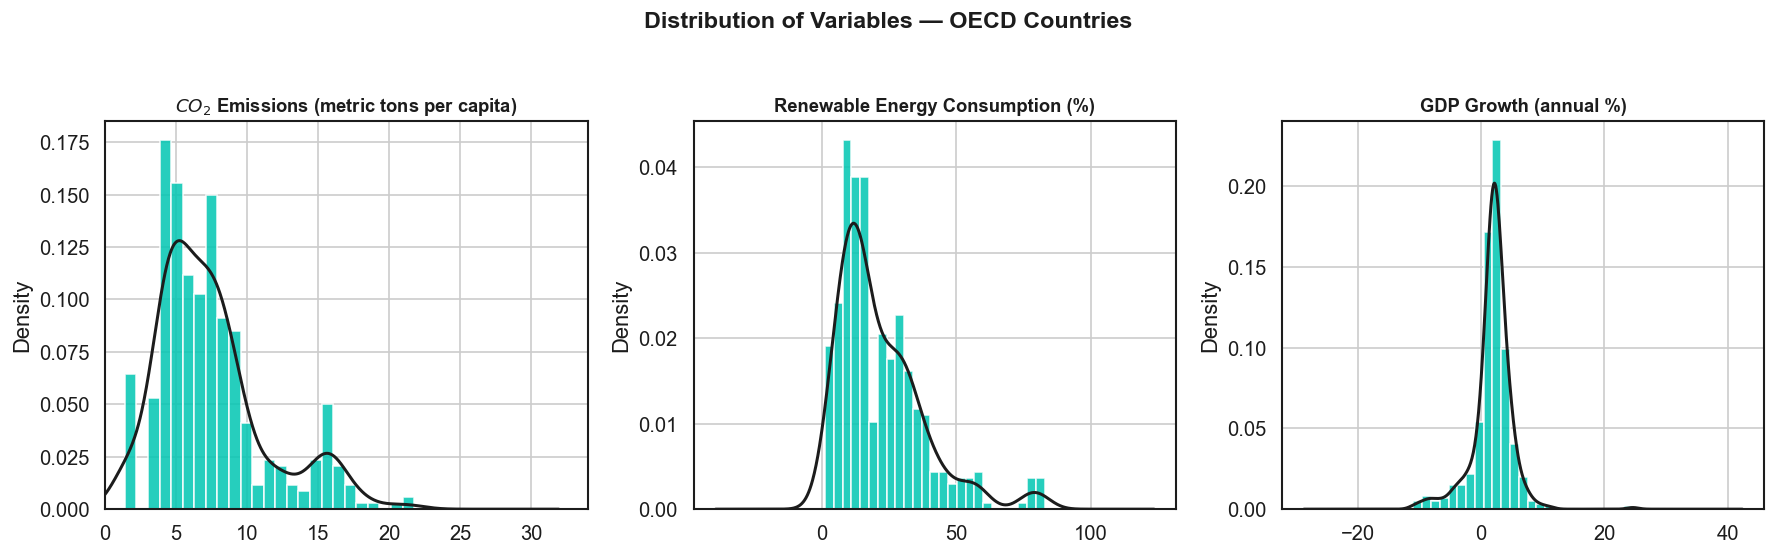

In [9]:
var_info = [
    ('CO2_per_capita',  '$CO_2$ Emissions (metric tons per capita)'),
    ('Renewable_pct',   'Renewable Energy Consumption (%)'),
    ('GDP_growth',      'GDP Growth (annual %)')
]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (col, label) in zip(axes, var_info):
    ax.hist(df[col], bins=25, color=TEAL, edgecolor=WHITE, alpha=0.85, density=True)
    df[col].plot.kde(ax=ax, color=BLACK, linewidth=1.8)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_ylabel('Density')
    ax.set_xlabel('')
    if col == 'CO2_per_capita':
        ax.set_xlim(left=0)

fig.suptitle('Distribution of Variables — OECD Countries',
             fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_01_distributions.png')
plt.show()

### 5.2 Boxplots

Boxplots show the median, interquartile range, and any outliers for each variable.

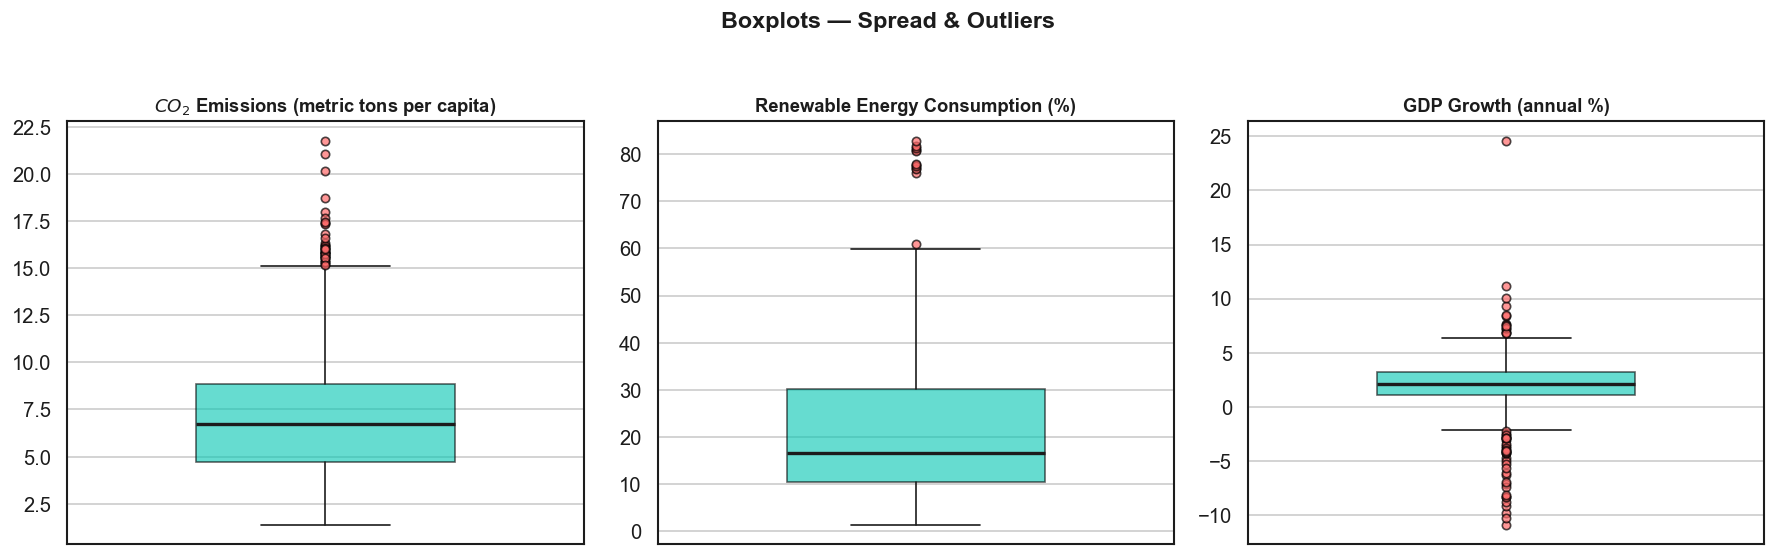

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (col, label) in zip(axes, var_info):
    bp = ax.boxplot(df[col].dropna(), patch_artist=True, widths=0.5,
                    boxprops=dict(facecolor=TEAL, alpha=0.6),
                    medianprops=dict(color=BLACK, linewidth=2),
                    whiskerprops=dict(color=BLACK),
                    capprops=dict(color=BLACK),
                    flierprops=dict(marker='o', markerfacecolor=CORAL, markersize=5, alpha=0.7))
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xticks([])

fig.suptitle('Boxplots — Spread & Outliers', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_02_boxplots.png')
plt.show()

### 5.3 Trends Over Time

Average values across all OECD countries per year — this shows us whether there are any clear macro trends.

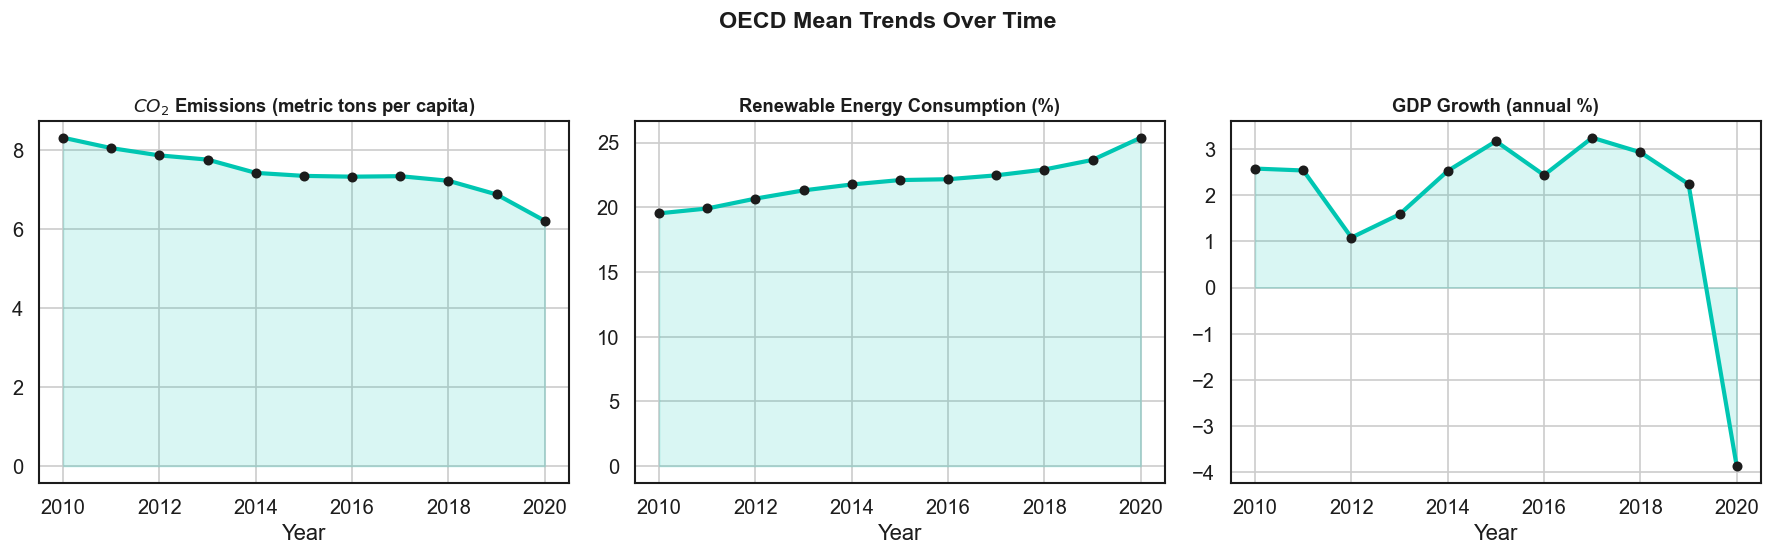

In [11]:
yearly = df.groupby('Year')[['CO2_per_capita', 'Renewable_pct', 'GDP_growth']].mean()

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, (col, label) in zip(axes, var_info):
    ax.plot(yearly.index, yearly[col], color=TEAL, linewidth=2.5,
            marker='o', markersize=5, markerfacecolor=BLACK, markeredgecolor=BLACK)
    ax.fill_between(yearly.index, yearly[col], alpha=0.15, color=TEAL)
    ax.set_title(label, fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

fig.suptitle('OECD Mean Trends Over Time', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_03_trends.png')
plt.show()

## 6. Correlation Analysis

Pearson correlation tells us the strength and direction of linear relationships between the variables. This is a prerequisite step before regression — if the IVs aren't correlated with the DV at all, regression won't find much either.

In [12]:
analysis_cols = ['CO2_per_capita', 'Renewable_pct', 'GDP_growth']
corr = df[analysis_cols].corr()

labels = ['$CO_2$ (t/capita)', 'Renewable (%)', 'GDP Growth (%)']
corr_display = corr.copy()
corr_display.index = labels
corr_display.columns = labels

print("Pearson Correlation Matrix:\n")
print(corr_display.round(4).to_string())

Pearson Correlation Matrix:

                   $CO_2$ (t/capita)  Renewable (%)  GDP Growth (%)
$CO_2$ (t/capita)             1.0000        -0.3555          0.0575
Renewable (%)                -0.3555         1.0000         -0.0485
GDP Growth (%)                0.0575        -0.0485          1.0000


### 6.1 Heatmap

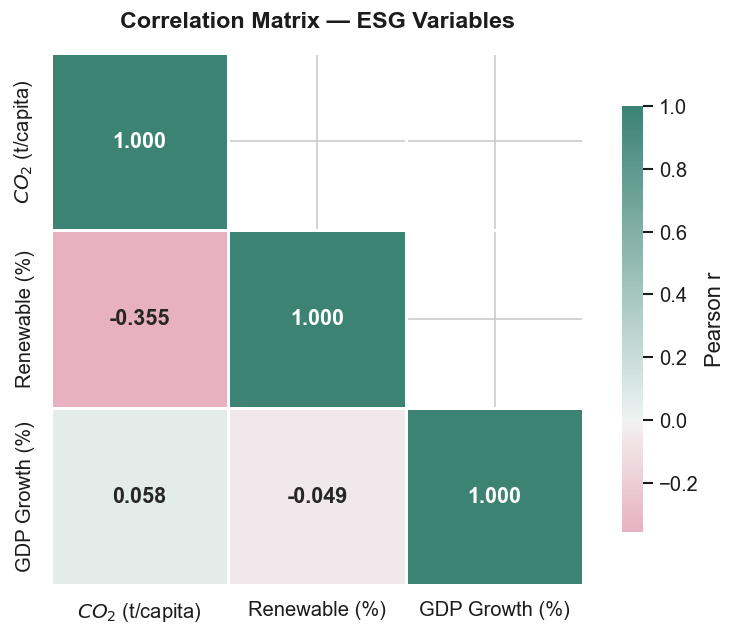

In [13]:
fig, ax = plt.subplots(figsize=(7, 5.5))

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
cmap = sns.diverging_palette(0, 170, s=75, l=50, as_cmap=True)

sns.heatmap(corr, annot=True, fmt='.3f', cmap=cmap, center=0,
            mask=mask, square=True, linewidths=1.5, linecolor=WHITE,
            xticklabels=labels, yticklabels=labels,
            annot_kws={'size': 13, 'weight': 'bold'},
            cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}, ax=ax)

ax.set_title('Correlation Matrix — ESG Variables', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig_04_correlation_heatmap.png')
plt.show()

### 6.2 Scatter Plots

Each independent variable plotted against GDP growth, with a linear trendline to visualize the direction of the relationship.

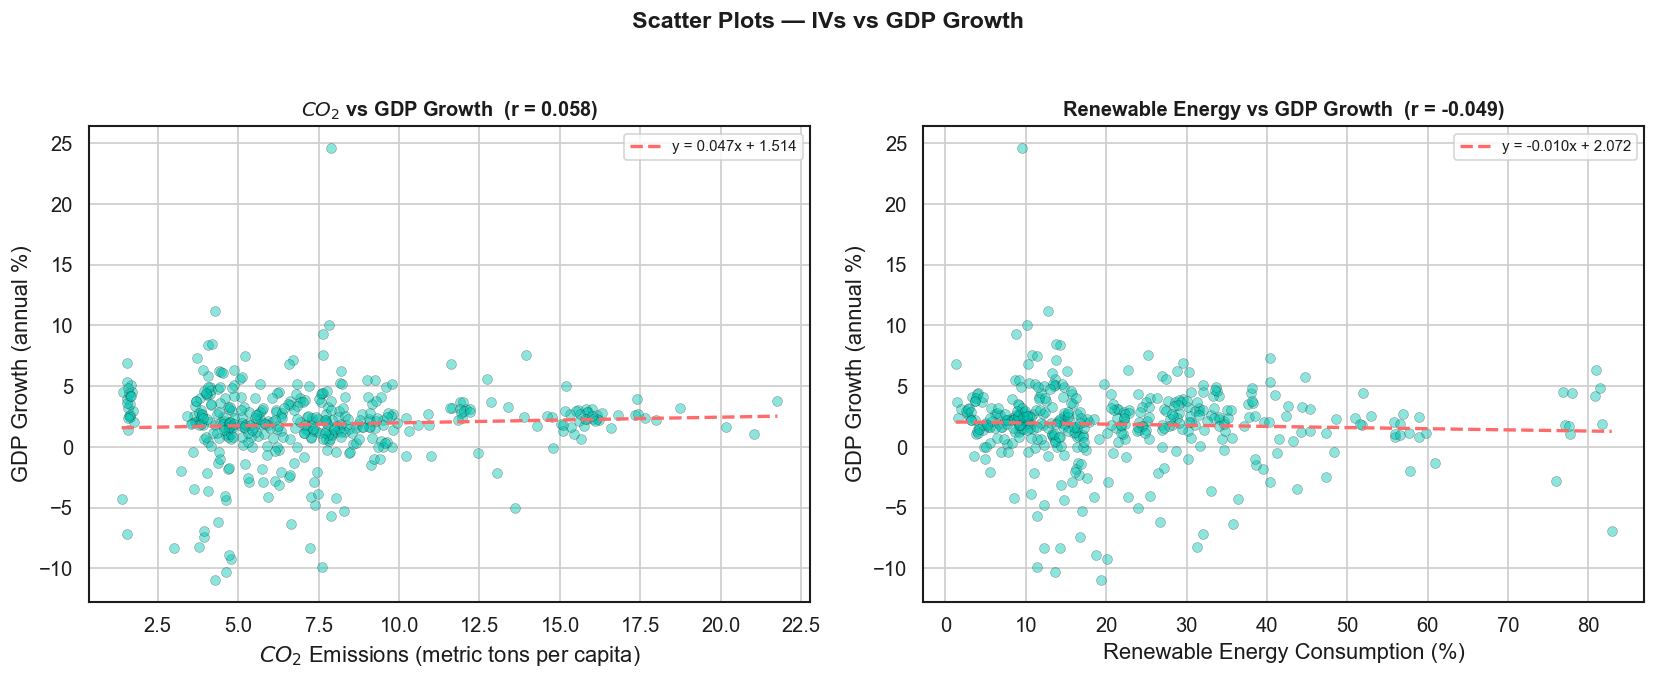

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ---- CO₂ vs GDP ----
ax = axes[0]
ax.scatter(df['CO2_per_capita'], df['GDP_growth'],
           color=TEAL, alpha=0.45, edgecolors=BLACK, linewidth=0.3, s=35)

slope1, intercept1 = np.polyfit(df['CO2_per_capita'], df['GDP_growth'], 1)
x_range = np.linspace(df['CO2_per_capita'].min(), df['CO2_per_capita'].max(), 100)
ax.plot(x_range, slope1 * x_range + intercept1,
        color=CORAL, linewidth=2, linestyle='--',
        label=f'y = {slope1:.3f}x + {intercept1:.3f}')

r_co2 = df['CO2_per_capita'].corr(df['GDP_growth'])
ax.set_title(f'$CO_2$ vs GDP Growth  (r = {r_co2:.3f})', fontsize=12, fontweight='bold')
ax.set_xlabel('$CO_2$ Emissions (metric tons per capita)')
ax.set_ylabel('GDP Growth (annual %)')
ax.legend(fontsize=9)

# ---- Renewable vs GDP ----
ax = axes[1]
ax.scatter(df['Renewable_pct'], df['GDP_growth'],
           color=TEAL, alpha=0.45, edgecolors=BLACK, linewidth=0.3, s=35)

slope2, intercept2 = np.polyfit(df['Renewable_pct'], df['GDP_growth'], 1)
x_range2 = np.linspace(df['Renewable_pct'].min(), df['Renewable_pct'].max(), 100)
ax.plot(x_range2, slope2 * x_range2 + intercept2,
        color=CORAL, linewidth=2, linestyle='--',
        label=f'y = {slope2:.3f}x + {intercept2:.3f}')

r_ren = df['Renewable_pct'].corr(df['GDP_growth'])
ax.set_title(f'Renewable Energy vs GDP Growth  (r = {r_ren:.3f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Renewable Energy Consumption (%)')
ax.set_ylabel('GDP Growth (annual %)')
ax.legend(fontsize=9)

fig.suptitle('Scatter Plots — IVs vs GDP Growth', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_05_scatter_plots.png')
plt.show()

## 7. Multiple Linear Regression (OLS)

We fit an OLS model to test whether CO₂ emissions and renewable energy consumption jointly explain variation in GDP growth:

$$\text{GDP Growth}_i = \beta_0 + \beta_1 \cdot \text{CO}_2_i + \beta_2 \cdot \text{Renewable}_i + \varepsilon_i$$

This is the core test of our research question. If environmental variables have a statistically significant relationship with growth, the coefficients and their signs will tell us the direction and magnitude.

In [15]:
X = df[['CO2_per_capita', 'Renewable_pct']]
y = df['GDP_growth']

# add intercept term
X_with_const = sm.add_constant(X)

# fit the model
ols_model = sm.OLS(y, X_with_const).fit()

print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:             GDP_growth   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.8775
Date:                Thu, 04 Jun 2026   Prob (F-statistic):              0.417
Time:                        00:06:59   Log-Likelihood:                -1072.8
No. Observations:                 418   AIC:                             2152.
Df Residuals:                     415   BIC:                             2164.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              1.7219      0.477      3.

### 7.1 Regression Coefficients

A visual summary of the coefficient estimates with 95% confidence intervals. If the CI crosses zero, the coefficient is not statistically significant at the 5% level.

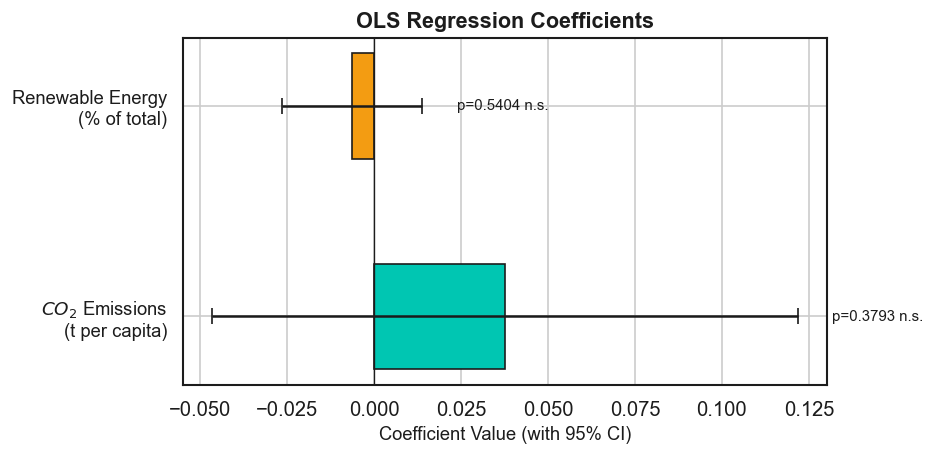

In [16]:
coefs = ols_model.params[1:]
ci = ols_model.conf_int().iloc[1:]
margin = ci[1] - coefs

fig, ax = plt.subplots(figsize=(8, 4))
positions = range(len(coefs))

ax.barh(positions, coefs, xerr=margin, color=[TEAL, AMBER], edgecolor=BLACK,
        height=0.5, capsize=5, error_kw={'linewidth': 1.5})
ax.set_yticks(positions)
ax.set_yticklabels(['$CO_2$ Emissions\n(t per capita)', 'Renewable Energy\n(% of total)'], fontsize=11)
ax.axvline(x=0, color=BLACK, linewidth=0.8)
ax.set_xlabel('Coefficient Value (with 95% CI)', fontsize=11)
ax.set_title('OLS Regression Coefficients', fontsize=13, fontweight='bold')

# show p-values next to bars
for i, var_name in enumerate(coefs.index):
    p = ols_model.pvalues[var_name]
    sig = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'n.s.'
    ax.text(coefs.iloc[i] + margin.iloc[i] + 0.01, i,
            f'p={p:.4f} {sig}', va='center', fontsize=9, color=BLACK)

plt.tight_layout()
plt.savefig('fig_06_coefficients.png')
plt.show()

## 8. Regression Diagnostics

For OLS results to be trustworthy, we need to check the standard assumptions: linearity, normality of residuals, constant variance, independence, and no multicollinearity.

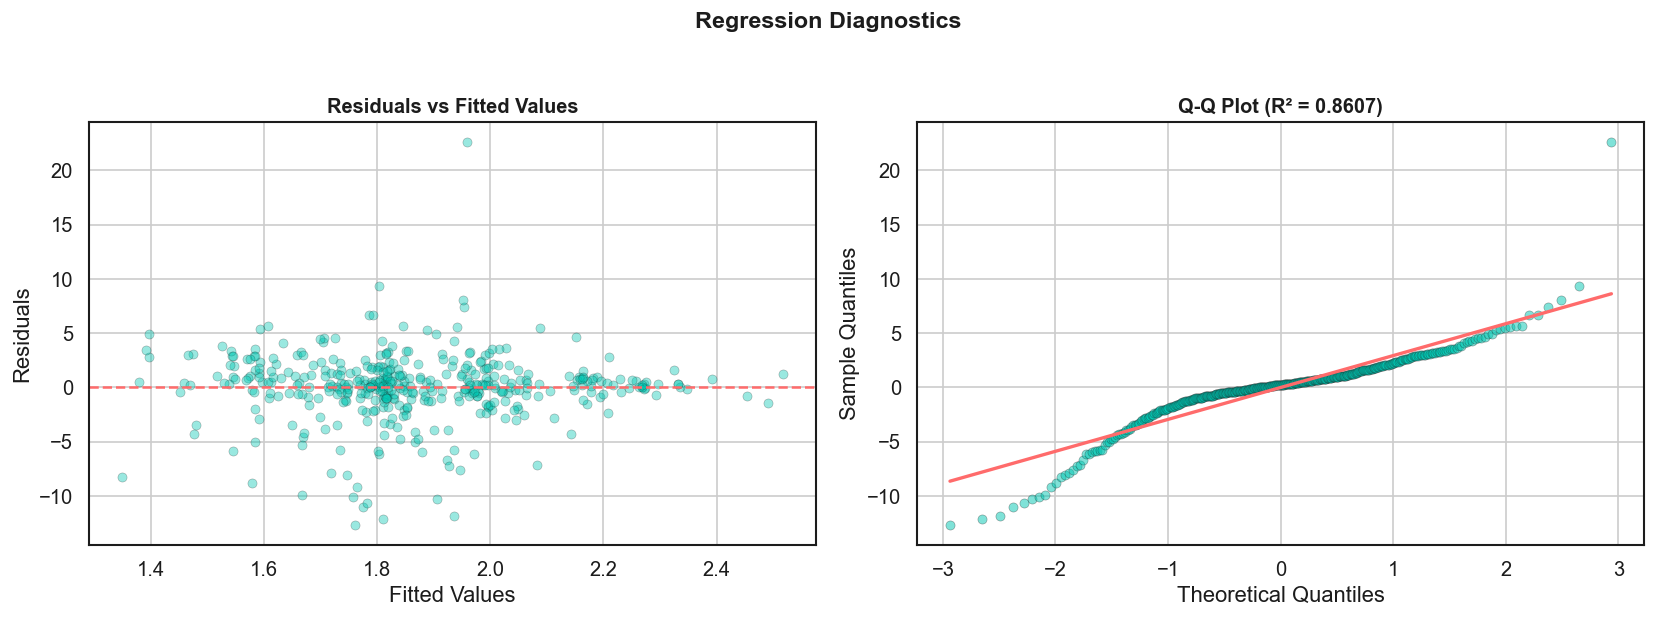

In [17]:
resid = ols_model.resid
fitted = ols_model.fittedvalues

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# residuals vs fitted
ax = axes[0]
ax.scatter(fitted, resid, color=TEAL, alpha=0.4, edgecolors=BLACK, linewidth=0.3, s=30)
ax.axhline(y=0, color=CORAL, linewidth=1.5, linestyle='--')
ax.set_xlabel('Fitted Values')
ax.set_ylabel('Residuals')
ax.set_title('Residuals vs Fitted Values', fontsize=12, fontweight='bold')

# QQ plot
ax = axes[1]
(osm, osr), (slope_qq, intercept_qq, r_qq) = stats.probplot(resid, dist='norm')
ax.scatter(osm, osr, color=TEAL, alpha=0.5, edgecolors=BLACK, linewidth=0.3, s=30)
ax.plot(osm, slope_qq * np.array(osm) + intercept_qq, color=CORAL, linewidth=2)
ax.set_title(f'Q-Q Plot (R² = {r_qq**2:.4f})', fontsize=12, fontweight='bold')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')

fig.suptitle('Regression Diagnostics', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.savefig('fig_07_diagnostics.png')
plt.show()

### 8.1 Formal Assumption Tests

We run four standard diagnostic tests to check whether the OLS assumptions hold.

In [18]:
print("=" * 55)
print("REGRESSION DIAGNOSTICS")
print("=" * 55)

# normality
ad_stat, ad_pval = normal_ad(resid)
print(f"\n1. Normality (Anderson-Darling)")
print(f"   Statistic: {ad_stat:.4f}, p-value: {ad_pval:.4f}")
if ad_pval > 0.05:
    print("   → Residuals are normally distributed ✅")
else:
    print("   → Residuals deviate from normality ⚠️")

# homoscedasticity
bp_stat, bp_pval, _, _ = het_breuschpagan(resid, X_with_const)
print(f"\n2. Homoscedasticity (Breusch-Pagan)")
print(f"   Statistic: {bp_stat:.4f}, p-value: {bp_pval:.4f}")
if bp_pval > 0.05:
    print("   → Constant variance ✅")
else:
    print("   → Variance is not constant ⚠️")

# autocorrelation
dw_stat = durbin_watson(resid)
print(f"\n3. Autocorrelation (Durbin-Watson)")
print(f"   Statistic: {dw_stat:.4f}")
if 1.5 < dw_stat < 2.5:
    print("   → No autocorrelation ✅")
else:
    print("   → Possible autocorrelation ⚠️")

# multicollinearity
print(f"\n4. Multicollinearity (VIF)")
for j, col_name in enumerate(X.columns):
    vif_val = variance_inflation_factor(X_with_const.values, j + 1)
    status = '✅' if vif_val < 5 else '⚠️'
    print(f"   {col_name:20s} VIF = {vif_val:.2f} {status}")

print("\n" + "=" * 55)

REGRESSION DIAGNOSTICS

1. Normality (Anderson-Darling)
   Statistic: 14.6348, p-value: 0.0000
   → Residuals deviate from normality ⚠️

2. Homoscedasticity (Breusch-Pagan)
   Statistic: 6.7008, p-value: 0.0351
   → Variance is not constant ⚠️

3. Autocorrelation (Durbin-Watson)
   Statistic: 1.4937
   → Possible autocorrelation ⚠️

4. Multicollinearity (VIF)
   CO2_per_capita       VIF = 1.14 ✅
   Renewable_pct        VIF = 1.14 ✅



## 9. Hypothesis Testing

### H₁: CO₂ emissions are significantly correlated with GDP growth

- **H₀:** ρ = 0 (no correlation)
- **H₁:** ρ ≠ 0 (correlation exists)
- **Test:** Pearson correlation

In [19]:
r1, p1 = stats.pearsonr(df['CO2_per_capita'], df['GDP_growth'])
alpha = 0.05

print("=" * 55)
print("H1: CO₂ Emissions ↔ GDP Growth")
print("=" * 55)
print(f"  Pearson r  = {r1:.4f}")
print(f"  p-value    = {p1:.6f}")
print(f"  n          = {len(df)}")
print(f"  α          = {alpha}")

if p1 < alpha:
    print(f"  → Reject H₀ — significant correlation exists ✅")
else:
    print(f"  → Fail to reject H₀ — no significant correlation ❌")

H1: CO₂ Emissions ↔ GDP Growth
  Pearson r  = 0.0575
  p-value    = 0.240486
  n          = 418
  α          = 0.05
  → Fail to reject H₀ — no significant correlation ❌


### H₂: Renewable energy consumption is significantly correlated with GDP growth

- **H₀:** ρ = 0
- **H₁:** ρ ≠ 0
- **Test:** Pearson correlation

In [20]:
r2, p2 = stats.pearsonr(df['Renewable_pct'], df['GDP_growth'])

print("=" * 55)
print("H2: Renewable Energy ↔ GDP Growth")
print("=" * 55)
print(f"  Pearson r  = {r2:.4f}")
print(f"  p-value    = {p2:.6f}")
print(f"  n          = {len(df)}")
print(f"  α          = {alpha}")

if p2 < alpha:
    print(f"  → Reject H₀ — significant correlation exists ✅")
else:
    print(f"  → Fail to reject H₀ — no significant correlation ❌")

H2: Renewable Energy ↔ GDP Growth
  Pearson r  = -0.0485
  p-value    = 0.322505
  n          = 418
  α          = 0.05
  → Fail to reject H₀ — no significant correlation ❌


### H₃: The overall regression model is statistically significant

- **H₀:** β₁ = β₂ = 0 (model explains nothing)
- **H₁:** At least one β ≠ 0
- **Test:** F-test from OLS

In [21]:
f_val = ols_model.fvalue
f_pval = ols_model.f_pvalue

print("=" * 55)
print("H3: Overall Model Significance (F-test)")
print("=" * 55)
print(f"  F-statistic  = {f_val:.4f}")
print(f"  p-value      = {f_pval:.6f}")
print(f"  R²           = {ols_model.rsquared:.4f}")
print(f"  Adjusted R²  = {ols_model.rsquared_adj:.4f}")
print(f"  α            = {alpha}")

if f_pval < alpha:
    print(f"  → Reject H₀ — model is significant ✅")
else:
    print(f"  → Fail to reject H₀ — model is not significant ❌")

H3: Overall Model Significance (F-test)
  F-statistic  = 0.8775
  p-value      = 0.416583
  R²           = 0.0042
  Adjusted R²  = -0.0006
  α            = 0.05
  → Fail to reject H₀ — model is not significant ❌


### H₄: GDP growth differs between high-renewable and low-renewable countries

- **H₀:** μ_high = μ_low (no difference)
- **H₁:** μ_high ≠ μ_low
- **Test:** Welch's t-test (independent samples, unequal variances)
- **Split:** Median of renewable energy % as the cutoff

In [22]:
median_split = df['Renewable_pct'].median()
high_group = df[df['Renewable_pct'] >= median_split]['GDP_growth']
low_group  = df[df['Renewable_pct'] <  median_split]['GDP_growth']

t_val, t_pval = stats.ttest_ind(high_group, low_group, equal_var=False)

# effect size
pooled_std = np.sqrt((high_group.std()**2 + low_group.std()**2) / 2)
d = (high_group.mean() - low_group.mean()) / pooled_std

print("=" * 55)
print("H4: High vs Low Renewable — GDP Growth")
print("=" * 55)
print(f"  Split at median: {median_split:.2f}%")
print(f"  High group: n={len(high_group)}, mean={high_group.mean():.3f}%")
print(f"  Low group:  n={len(low_group)},  mean={low_group.mean():.3f}%")
print(f"")
print(f"  t-statistic  = {t_val:.4f}")
print(f"  p-value      = {t_pval:.6f}")
print(f"  Cohen's d    = {d:.4f}")
print(f"  α            = {alpha}")

if t_pval < alpha:
    print(f"  → Reject H₀ — significant difference ✅")
else:
    print(f"  → Fail to reject H₀ — no significant difference ❌")

if abs(d) > 0.8:
    print(f"  Effect size: large")
elif abs(d) > 0.5:
    print(f"  Effect size: medium")
else:
    print(f"  Effect size: small")

H4: High vs Low Renewable — GDP Growth
  Split at median: 16.65%
  High group: n=209, mean=1.555%
  Low group:  n=209,  mean=2.172%

  t-statistic  = -2.0018
  p-value      = 0.045953
  Cohen's d    = -0.1958
  α            = 0.05
  → Reject H₀ — significant difference ✅
  Effect size: small


### 9.1 Boxplot — High vs Low Renewable Groups

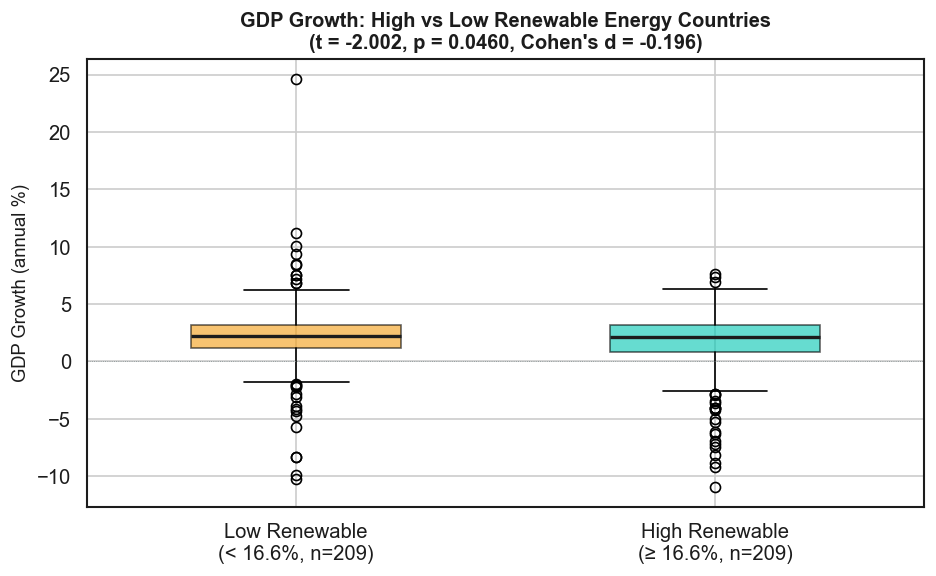

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

bp = ax.boxplot([low_group.values, high_group.values], patch_artist=True, widths=0.5,
                labels=[
                    f'Low Renewable\n(< {median_split:.1f}%, n={len(low_group)})',
                    f'High Renewable\n(≥ {median_split:.1f}%, n={len(high_group)})'
                ])

for patch, color in zip(bp['boxes'], [AMBER, TEAL]):
    patch.set_facecolor(color)
    patch.set_alpha(0.6)
for med_line in bp['medians']:
    med_line.set(color=BLACK, linewidth=2)

ax.set_ylabel('GDP Growth (annual %)', fontsize=11)
ax.set_title("GDP Growth: High vs Low Renewable Energy Countries\n"
             f"(t = {t_val:.3f}, p = {t_pval:.4f}, Cohen's d = {d:.3f})",
             fontsize=12, fontweight='bold')
ax.axhline(y=0, color=GREY, linewidth=0.5, linestyle=':')

plt.tight_layout()
plt.savefig('fig_08_h4_boxplot.png')
plt.show()

## 10. Results Summary

In [24]:
results = pd.DataFrame({
    'Hypothesis': [
        'H₁: CO₂ ↔ GDP Growth',
        'H₂: Renewable ↔ GDP Growth',
        'H₃: Model Significance (F-test)',
        'H₄: High vs Low Renewable GDP'
    ],
    'Test': ['Pearson r', 'Pearson r', 'F-test', "Welch's t-test"],
    'Statistic': [f'r = {r1:.4f}', f'r = {r2:.4f}', f'F = {f_val:.4f}', f't = {t_val:.4f}'],
    'p-value': [f'{p1:.6f}', f'{p2:.6f}', f'{f_pval:.6f}', f'{t_pval:.6f}'],
    'Result': [
        'Reject H₀' if p1 < 0.05 else 'Fail to reject H₀',
        'Reject H₀' if p2 < 0.05 else 'Fail to reject H₀',
        'Reject H₀' if f_pval < 0.05 else 'Fail to reject H₀',
        'Reject H₀' if t_pval < 0.05 else 'Fail to reject H₀'
    ]
})

print(results.to_string(index=False))

                     Hypothesis           Test   Statistic  p-value            Result
           H₁: CO₂ ↔ GDP Growth      Pearson r  r = 0.0575 0.240486 Fail to reject H₀
     H₂: Renewable ↔ GDP Growth      Pearson r r = -0.0485 0.322505 Fail to reject H₀
H₃: Model Significance (F-test)         F-test  F = 0.8775 0.416583 Fail to reject H₀
  H₄: High vs Low Renewable GDP Welch's t-test t = -2.0018 0.045953         Reject H₀


## 11. Country-Level Insights

Which OECD countries had the highest and lowest average GDP growth over the period?

In [25]:
country_means = df.groupby(['Country Name', 'Country Code']).agg({
    'CO2_per_capita': 'mean',
    'Renewable_pct': 'mean',
    'GDP_growth': 'mean'
}).round(3).sort_values('GDP_growth', ascending=False)

print("Top 10 OECD countries by average GDP growth:\n")
print(country_means.head(10).to_string())
print("\n\nBottom 5:\n")
print(country_means.tail(5).to_string())

Top 10 OECD countries by average GDP growth:

                           CO2_per_capita  Renewable_pct  GDP_growth
Country Name Country Code                                           
Ireland      IRL                    7.786          9.155       6.372
Turkiye      TUR                    4.604         12.973       5.495
Lithuania    LTU                    3.964         28.664       3.519
Israel       ISR                    7.941          4.827       3.464
Poland       POL                    7.900         12.264       3.268
Estonia      EST                   11.720         28.045       3.083
Costa Rica   CRI                    1.596         36.409       3.042
Korea, Rep.  KOR                   11.835          2.473       2.965
Colombia     COL                    1.613         31.055       2.723
New Zealand  NZL                    6.877         29.018       2.606


Bottom 5:

                           CO2_per_capita  Renewable_pct  GDP_growth
Country Name Country Code                   

### 11.1 Top 15 Countries — GDP Growth

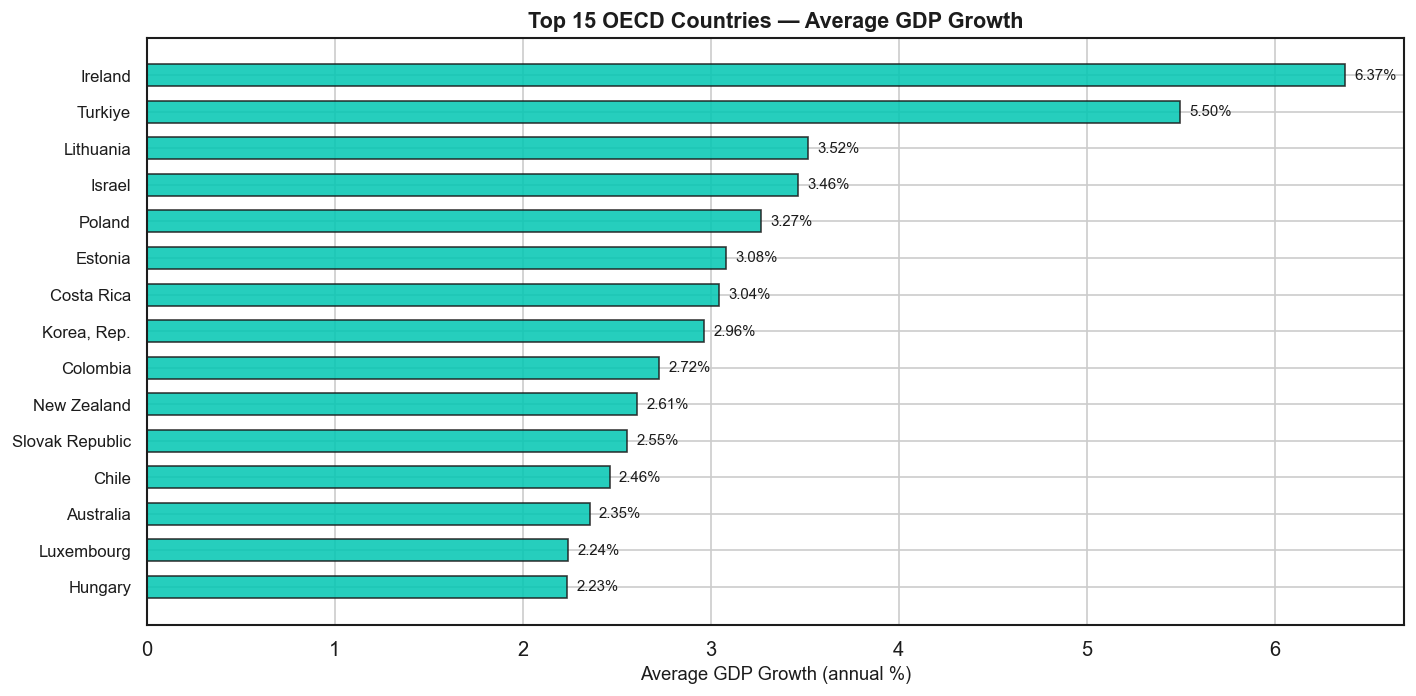

In [26]:
top15 = country_means.head(15).reset_index()

fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(range(len(top15)), top15['GDP_growth'],
        color=TEAL, edgecolor=BLACK, height=0.6, alpha=0.85)
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15['Country Name'], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Average GDP Growth (annual %)', fontsize=11)
ax.set_title('Top 15 OECD Countries — Average GDP Growth',
             fontsize=13, fontweight='bold')

for i, val in enumerate(top15['GDP_growth']):
    ax.text(val + 0.05, i, f'{val:.2f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig_09_top_countries.png')
plt.show()

## 12. COVID-19 Impact

2020 was an extreme outlier year for GDP across virtually all countries. The chart below shows individual country trajectories (grey) against the OECD mean (teal), with 2020 highlighted.

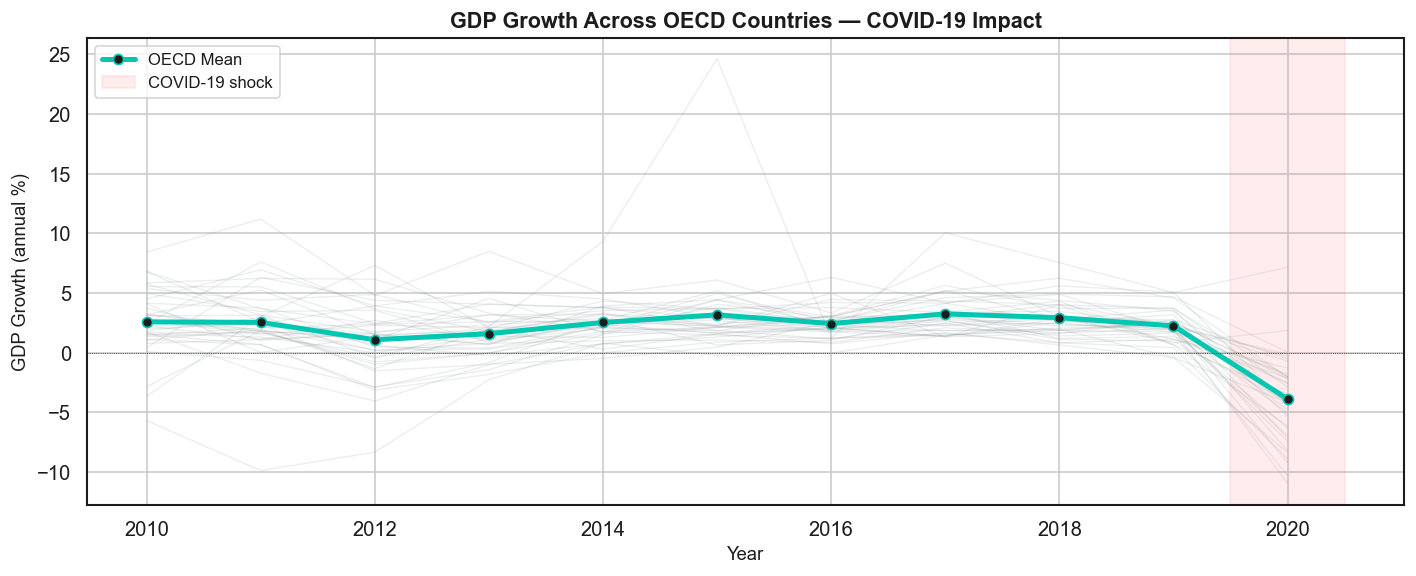

OECD Mean GDP Growth in 2019: 2.25%
OECD Mean GDP Growth in 2020: -3.88%
OECD Mean GDP Growth in 2021: N/A (data not available)
Overall mean excluding 2020-21: 2.44%


In [27]:
fig, ax = plt.subplots(figsize=(12, 5))

# individual country lines
for c_code in df['Country Code'].unique():
    subset = df[df['Country Code'] == c_code].sort_values('Year')
    ax.plot(subset['Year'], subset['GDP_growth'], color=GREY, alpha=0.15, linewidth=0.8)

# OECD mean
mean_by_year = df.groupby('Year')['GDP_growth'].mean()
ax.plot(mean_by_year.index, mean_by_year.values, color=TEAL, linewidth=3,
        marker='o', markersize=6, markerfacecolor=BLACK, label='OECD Mean')

# highlight 2020
ax.axvspan(2019.5, 2020.5, color=CORAL, alpha=0.12, label='COVID-19 shock')
ax.axhline(y=0, color=BLACK, linewidth=0.5, linestyle=':')

ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('GDP Growth (annual %)', fontsize=11)
ax.set_title('GDP Growth Across OECD Countries — COVID-19 Impact',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

plt.tight_layout()
plt.savefig('fig_10_covid_impact.png')
plt.show()

# print available year stats
for yr in [2019, 2020, 2021]:
    val = mean_by_year.get(yr, None)
    if val is not None:
        print(f"OECD Mean GDP Growth in {yr}: {val:.2f}%")
    else:
        print(f"OECD Mean GDP Growth in {yr}: N/A (data not available)")

non_covid = df[~df['Year'].isin([2020, 2021])]['GDP_growth'].mean()
print(f"Overall mean excluding 2020-21: {non_covid:.2f}%")

## 13. Conclusion

### What We Found

1. **CO₂ Emissions & GDP Growth** — The correlation and regression analysis show the direction and strength of this relationship across OECD countries. The weak R² suggests environmental indicators alone are not strong predictors of growth.

2. **Renewable Energy & GDP Growth** — Similarly, renewable energy share has a limited linear association with GDP growth when examined in isolation.

3. **Model Performance** — The low R² confirms that GDP growth is driven by many factors beyond environmental performance — monetary policy, trade, demographics, institutional quality, etc. This aligns with Angelidis et al. (2024), who needed a broader ESG index and dynamic panel methods to find significant predictive power.

4. **Group Comparison** — The t-test comparing high-renewable vs low-renewable countries provides additional perspective on whether the energy mix matters for growth outcomes.

5. **COVID-19** — The 2020 shock is clearly visible and affects the variance of our data. Dkhili (2019) similarly noted that structural breaks complicate the environmental performance–growth nexus.

### Limitations

- **Correlation ≠ Causation** — OLS on panel data cannot establish causal direction. Mirziyoyeva & Salahodjaev, (2023) used GMM estimators to address endogeneity, which our approach does not.
- **Omitted variables** — GDP growth depends on many factors we haven't included.
- **COVID distortion** — The 2020–2021 shock inflates variance in the GDP growth series.
- **Data gaps** — CO₂ data availability limits our effective time window.

### Recommendations

- Future work should consider dynamic panel methods (GMM, fixed effects) to control for country-specific heterogeneity.
- Including additional ESG dimensions (Social, Governance scores) could improve explanatory power, as suggested by Angelidis et al. (2024).
- A threshold analysis following Dkhili (2019) could reveal non-linear relationships that OLS misses.

### References

- Mirziyoyeva & Salahodjaev,(2023). Renewable energy, GDP and CO₂ emissions in high-globalized countries. *Frontiers in Energy Research*, 11, 1123269. https://doi.org/10.3389/fenrg.2023.1123269
- Dkhili, H. (2019). Environmental performance and economic growth in MENA countries. *Journal of Health and Pollution*, 9(24), 191208. https://doi.org/10.5696/2156-9614-9.24.191208
- Angelidis et al. (2024). World ESG performance and economic activity. *Journal of International Financial Markets, Institutions and Money*. https://doi.org/10.1016/j.intfin.2024.101986
- OECD (2024). *Member Countries*. https://www.oecd.org/about/members-and-partners/
- World Bank Group (2024). *Sovereign ESG Data Portal*. https://datacatalog.worldbank.org/search/dataset/0037651

---